# Evaluación y Comparación de Modelos

Para evaluar modelos de volatilidad, no basta con mirar el error absoluto. Usaremos una métrica específica de las finanzas cuantitativas llamada QLIKE (Quasi-Likelihood), que penaliza más fuertemente cuando el modelo subestima la volatilidad (lo cual, en gestión de riesgos y pricing, es mucho más peligroso que sobreestimarla).\
La ecuación matemática de la pérdida QLIKE es:
$$QLIKE = \frac{\sigma^2_{real}}{\sigma^2_{pred}} - \ln\left(\frac{\sigma^2_{real}}{\sigma^2_{pred}}\right) - 1$$

# 1. Carga y Consolidación de Resultados

Primero, necesitamos unificar las predicciones que guardamos en los Notebooks 2 y 3. Usaremos la fecha como índice.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

garch_df = pd.read_csv('../data/processed/garch_predictions.csv', index_col='Date', parse_dates=True)
dl_df = pd.read_csv('../data/processed/dl_predictions.csv', index_col='Date', parse_dates=True)
xgb_df = pd.read_csv('../data/processed/xgboost_predictions.csv', index_col='Date', parse_dates=True)


columna_xgb = [col for col in xgb_df.columns if 'XGBoost' in col][0]
df_eval = garch_df[['Realized_Vol', 'GARCH_Pred_Vol']].copy()

# Unimos los modelos de Deep Learning y XGBoost (Inner Join asegura coincidencia exacta de fechas)
df_eval = df_eval.join(dl_df[['LSTM_Pred', 'Transformer_Pred']], how='inner')
df_eval = df_eval.join(xgb_df[[columna_xgb]], how='inner')

# Estandarizamos los nombres
df_eval.rename(columns={'Realized_Vol': 'Target', columna_xgb: 'XGBoost_Pred'}, inplace=True)

print(f"Total de días a evaluar: {len(df_eval)}")
print(f"Columnas listas: {df_eval.columns.tolist()}")
print(df_eval.head())

Total de días a evaluar: 512
Columnas listas: ['Target', 'GARCH_Pred_Vol', 'LSTM_Pred', 'Transformer_Pred', 'XGBoost_Pred']
              Target  GARCH_Pred_Vol  LSTM_Pred  Transformer_Pred  \
Date                                                                
2024-03-28  0.099038        0.109189   0.125983          0.113156   
2024-04-01  0.099380        0.104269   0.126270          0.112761   
2024-04-02  0.098266        0.100597   0.126179          0.111717   
2024-04-03  0.098101        0.103996   0.126274          0.111476   
2024-04-04  0.101425        0.099535   0.126884          0.110892   

            XGBoost_Pred  
Date                      
2024-03-28      0.103508  
2024-04-01      0.102767  
2024-04-02      0.103883  
2024-04-03      0.103005  
2024-04-04      0.104413  


# 2. Creación del Modelo "Ensemble" (Híbrido)

A menudo, en Machine Learning, la combinación de dos modelos que aprenden de maneras fundamentalmente distintas (estadística vs. redes neuronales) supera a los modelos individuales. Crearemos un ensamble simple promediando las predicciones de GARCH (experto en reversión a la media) y el Transformer (experto en memoria a largo plazo).

In [3]:
# Promedio simple entre nuestro modelo estadístico base y nuestra mejor red neuronal
df_eval['Ensemble_Pred'] = (df_eval['GARCH_Pred_Vol'] + df_eval['Transformer_Pred']) / 2

# Definimos la lista final definitiva con TODOS los modelos
model_names = ['GARCH_Pred_Vol', 'LSTM_Pred', 'Transformer_Pred', 'XGBoost_Pred', 'Ensemble_Pred']

# 3. Cálculo de Métricas de Error

Definiremos nuestras métricas y crearemos una tabla resumen. Usaremos MSE, MAE y QLIKE.

In [4]:
def qlike_loss(y_true, y_pred):
    var_true = np.square(np.maximum(y_true, 1e-8))
    var_pred = np.square(np.maximum(y_pred, 1e-8))
    return np.mean(var_true / var_pred - np.log(var_true / var_pred) - 1)

resultados = []

for model in model_names:
    y_true = df_eval['Target']
    y_pred = df_eval[model]
    
    resultados.append({
        'Modelo': model.replace('_Pred_Vol', '').replace('_Pred', ''),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'QLIKE': qlike_loss(y_true, y_pred)
    })

# Creamos el DataFrame final y lo mostramos ordenado por QLIKE (menor es mejor)
df_metrics = pd.DataFrame(resultados).set_index('Modelo')

print("\n--- Comparativa de Errores Final ---")
print(df_metrics.sort_values('QLIKE').round(4))


--- Comparativa de Errores Final ---
               RMSE     MAE   QLIKE
Modelo                             
XGBoost      0.0169  0.0088  0.0178
GARCH        0.0362  0.0222  0.0630
Ensemble     0.0445  0.0311  0.1150
LSTM         0.0590  0.0463  0.1919
Transformer  0.0694  0.0462  0.2059


Observamos que **el mejor modelo es XGBoost**, seguido por **GARCH**.\
Un modelo estadístico de los años 80 supera a las redes neuronales en las tres métricas. GARCH fue diseñado específicamente para modelar volatilidad financiera, mientras que LSTM y Transformer son modelos generalistas.

# 4. Evaluación Visual de los Modelos

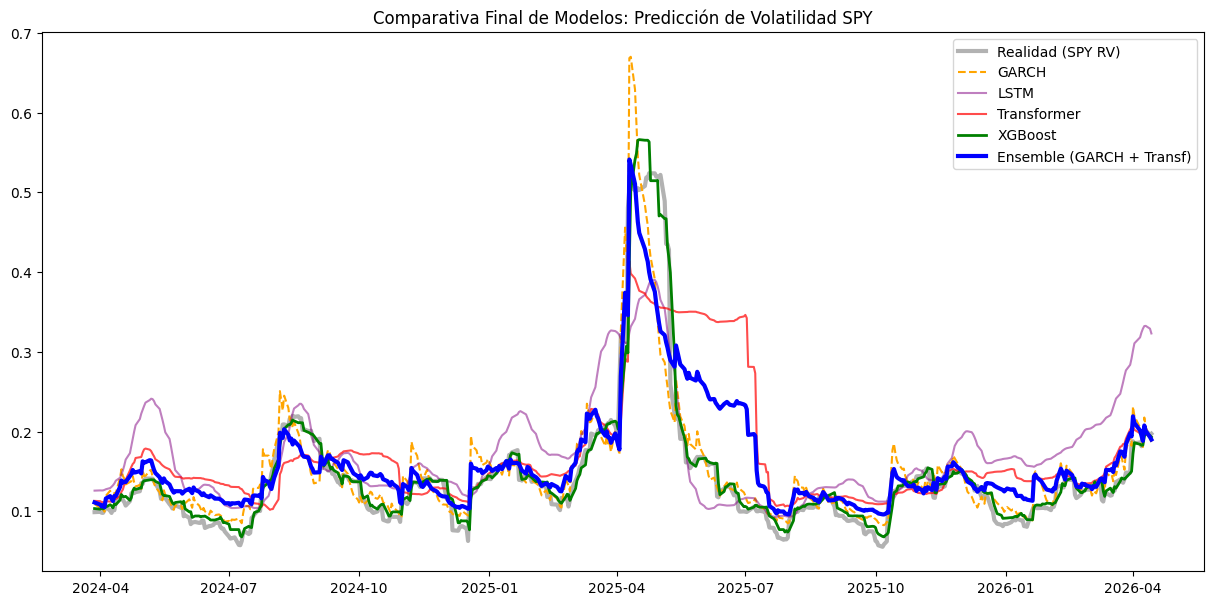

In [5]:
# Gráfico 1: Serie Temporal Completa 
plt.figure(figsize=(15, 7))

# Target (Realidad)
plt.plot(df_eval.index, df_eval['Target'], label='Realidad (SPY RV)', color='black', alpha=0.3, linewidth=3)

# Modelos Individuales
plt.plot(df_eval.index, df_eval['GARCH_Pred_Vol'], label='GARCH', color='orange', linestyle='--')
plt.plot(df_eval.index, df_eval['LSTM_Pred'], label='LSTM', color='purple', alpha=0.5) # Añadido LSTM
plt.plot(df_eval.index, df_eval['Transformer_Pred'], label='Transformer', color='red', alpha=0.7)
plt.plot(df_eval.index, df_eval['XGBoost_Pred'], label='XGBoost', color='green', linewidth=2)

# Ensemble
plt.plot(df_eval.index, df_eval['Ensemble_Pred'], label='Ensemble (GARCH + Transf)', color='blue', linewidth=3)

plt.title('Comparativa Final de Modelos: Predicción de Volatilidad SPY')
plt.legend()
plt.show()



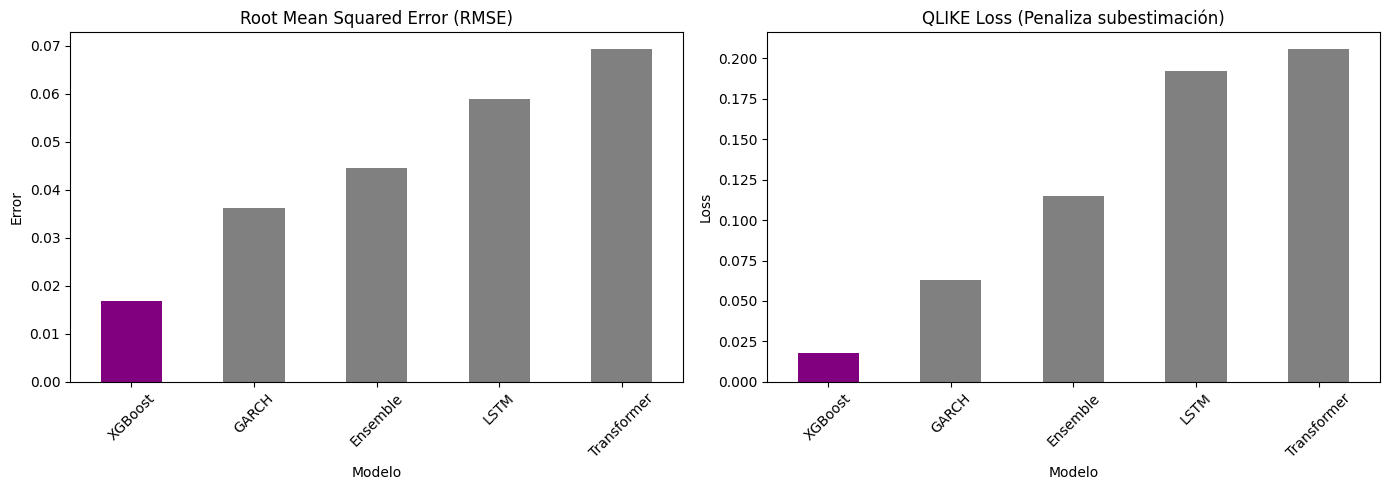

In [6]:
# Gráfico 2: Comparativa de Errores 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Creamos la lista de colores dinámicamente según la cantidad de modelos en df_metrics.
# El primer valor (el error más bajo tras ordenar) será morado, los demás grises.
colores_dinamicos = ['purple'] + ['gray'] * (len(df_metrics) - 1)

# Plot RMSE
df_metrics['RMSE'].sort_values().plot(kind='bar', ax=axes[0], color=colores_dinamicos)
axes[0].set_title('Root Mean Squared Error (RMSE)')
axes[0].set_ylabel('Error')
axes[0].tick_params(axis='x', rotation=45)

# Plot QLIKE
df_metrics['QLIKE'].sort_values().plot(kind='bar', ax=axes[1], color=colores_dinamicos)
axes[1].set_title('QLIKE Loss (Penaliza subestimación)')
axes[1].set_ylabel('Loss')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Conclusión**:
1. XGBoost es el ganador indiscutible. Tiene el error más bajo en ambas métricas (barras moradas en RMSE y QLIKE). En la gráfica temporal, es el único modelo (línea verde) que logra calcar casi a la perfección los movimientos de la volatilidad real (línea gris), especialmente durante el choque extremo de mediados de 2025.

2. GARCH obtiene el segundo lugar. El modelo estadístico tradicional demuestra ser muy robusto. Reacciona rápido a los shocks del mercado (aunque sobrestima ligeramente el gran pico) y logra mejores métricas de error que cualquier red neuronal profunda.

3. Fracaso del Deep Learning (LSTM y Transformer): Son los peores modelos en este proyecto. En el gráfico temporal se observa cómo fracasan al intentar capturar el pico súbito de volatilidad: el LSTM (morado) reacciona tarde y lo suaviza en exceso, mientras que el Transformer (rojo) se queda "atascado" prediciendo alta volatilidad mucho después de que el mercado se haya calmado.

3. El Ensemble fue lastrado: Al crear el híbrido promediando GARCH (buen rendimiento) con el Transformer (mal rendimiento), tu Ensemble (línea azul gruesa) quedó relegado a un mediocre tercer lugar, absorbiendo los errores de la red neuronal.

# 5. Selección Final y Exportación para el Pricing

Aquí decidimos qué modelo pasa a producción (es decir, al Notebook 5). Normalmente, elegiremos el que tenga el mejor balance entre RMSE y QLIKE. Como vemos, el mejor es el GARCH.

In [7]:
mejor_modelo = 'XGBoost_Pred'

print(f"Modelo seleccionado para producción: {mejor_modelo}")

# Creamos el dataframe final para el Notebook 5
# Nos quedamos con el target real y nuestra predicción ganadora de XGBoost
df_final_pricing = df_eval[['Target', mejor_modelo]].copy()

# Renombramos la columna para estandarizarla en el próximo notebook (Black-Scholes)
df_final_pricing.rename(columns={mejor_modelo: 'Forecasted_Vol'}, inplace=True)

df_final_pricing.to_csv('../data/processed/final_volatility_forecast.csv')


Modelo seleccionado para producción: XGBoost_Pred


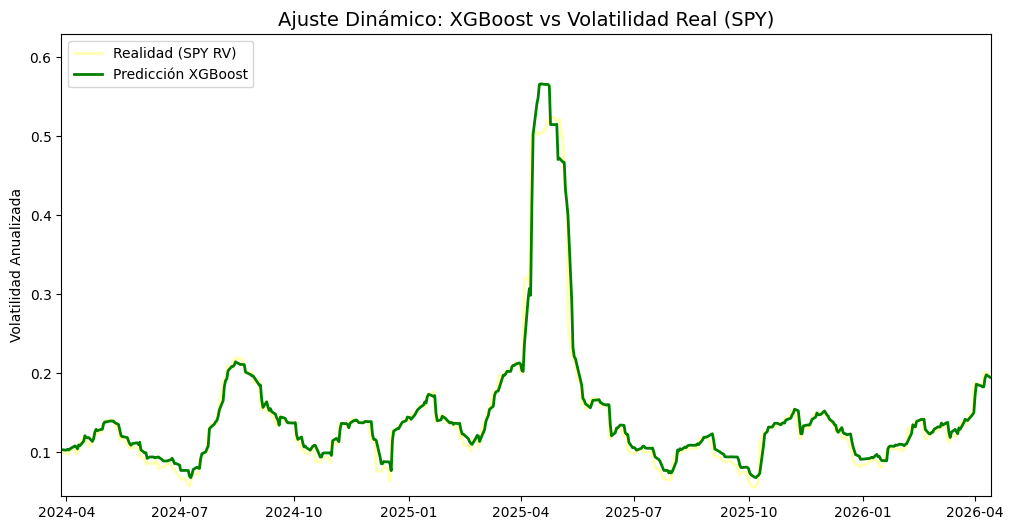

In [10]:
from matplotlib.animation import FuncAnimation

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(df_eval.index[0], df_eval.index[-1])
ax.set_ylim(df_eval['Target'].min() * 0.8, df_eval['Target'].max() * 1.2)
ax.set_title('Ajuste Dinámico: XGBoost vs Volatilidad Real (SPY)', fontsize=14)
ax.set_ylabel('Volatilidad Anualizada')

# Líneas que se irán dibujando
line_real, = ax.plot([], [], color='yellow', alpha=0.3, label='Realidad (SPY RV)', linewidth=2)
line_xgb, = ax.plot([], [], color='green', label='Predicción XGBoost', linewidth=2)
ax.legend(loc='upper left')

# Función de inicialización
def init():
    line_real.set_data([], [])
    line_xgb.set_data([], [])
    return line_real, line_xgb

# Función que actualiza el gráfico en cada frame
def update(frame):
    x = df_eval.index[:frame]
    y_real = df_eval['Target'][:frame]
    y_xgb = df_eval['XGBoost_Pred'][:frame]
    
    line_real.set_data(x, y_real)
    line_xgb.set_data(x, y_xgb)
    return line_real, line_xgb

# Crear la animación
# frames: número de puntos de datos; interval: milisegundos entre frames
ani = FuncAnimation(fig, update, frames=len(df_eval), init_func=init, blit=True, interval=20)

# Guardamos el gift
ani.save('xgboost_fitting.gif', writer='pillow', fps=30)

plt.show()

plt.show()